# Hough Circles (structured version)

Same logic as your original notebook, reorganized for readability.

⚠️ param1 is computed dynamically (NOT taken from preset).


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [9]:
# -----------------------------
# Configuration
# -----------------------------

#path = "data/images/gp6/64.jpg"
path = "data/images/gp4/4.jpg"

TARGET_W, TARGET_H = 640, 480

CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

GAUSS_KSIZE = 5
GAUSS_SIGMA = 2

# Presets: param1 REMOVED on purpose (param1 is dynamic)
HOUGH_PRESETS = {
    "red_coins_image": {
        "dp": 1.4,
        "minDist": 40,
        "param2": 70,
    },
    "gray_bg_image": {
        "dp": 1.4,
        "minDist": 40,
        "param2": 65,
    },
    "exp":{
        "dp": 1.15, #1.1 works for gray but 1.2 for red idk why so 1.15 is good
        "minDist": 30,
        "param2": 60,
    }
}

ACTIVE_HOUGH_PRESET = "exp"#"red_coins_image"

CIRCLE_OUTLINE_COLOR = (0, 255, 0)
CIRCLE_OUTLINE_THICKNESS = 2
CENTER_COLOR = (255, 0, 0)
CENTER_RADIUS = 2
CENTER_THICKNESS = 3

FIGSIZE = (8, 8)


In [10]:
# -----------------------------
# Helpers
# -----------------------------

def resolve_image_path(relative_path: str) -> Path:
    p = Path(relative_path)
    if not p.exists():
        p = Path("../" + relative_path)
    return p


def read_bgr_or_raise(image_path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image at {image_path.resolve()}")
    return image_bgr


def letterbox_resize_to_canvas(image_bgr: np.ndarray, target_w: int, target_h: int) -> np.ndarray:
    h, w = image_bgr.shape[:2]
    scale = min(target_w / w, target_h / h)
    new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))

    resized = cv2.resize(
        image_bgr,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR,
    )

    canvas = np.zeros((target_h, target_w, 3), dtype=np.uint8)
    x_off = (target_w - new_w) // 2
    y_off = (target_h - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas


def show_image(img, title: str, cmap=None) -> None:
    plt.figure(figsize=FIGSIZE)
    if cmap is None:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


def apply_clahe_on_l_channel(image_bgr: np.ndarray,
                             clip_limit: float,
                             tile_grid_size: tuple[int, int]) -> tuple[np.ndarray, np.ndarray]:
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_clahe = clahe.apply(l_channel)

    clahe_bgr = cv2.cvtColor(cv2.merge((l_clahe, a_channel, b_channel)), cv2.COLOR_LAB2BGR)
    clahe_rgb = cv2.cvtColor(clahe_bgr, cv2.COLOR_BGR2RGB)
    return clahe_bgr, clahe_rgb


def auto_hough_param1_from_gradient(gray_u8: np.ndarray,
                                    blur_ksize: int = 5,
                                    perc: float = 90.0,
                                    scale: float = 1.0,
                                    clamp=(20, 250)):
    """Pick Hough param1 (upper Canny threshold) from gradient magnitude."""
    if gray_u8.ndim != 2:
        raise ValueError("expected 2D grayscale")
    if gray_u8.dtype != np.uint8:
        gray_u8 = np.clip(gray_u8, 0, 255).astype(np.uint8)

    if blur_ksize and blur_ksize >= 3:
        if blur_ksize % 2 == 0:
            blur_ksize += 1
        g = cv2.GaussianBlur(gray_u8, (blur_ksize, blur_ksize), 0)
    else:
        g = gray_u8

    gx = cv2.Scharr(g, cv2.CV_32F, 1, 0)
    gy = cv2.Scharr(g, cv2.CV_32F, 0, 1)
    mag = cv2.magnitude(gx, gy)

    m = mag[mag > 1e-3]
    if m.size == 0:
        return 100

    t = np.percentile(m, perc) * scale
    return int(np.clip(t, clamp[0], clamp[1]))

def auto_minradius_plateau(
    blurred: np.ndarray,
    base_params: dict,
    minR_start: int = 10,
    minR_end: int = 120,
    step: int = 2,
    keep_top_k: int = 20,
):
    """
    Rule:
    1) Sweep minR.
    2) Keep only "good" results: nested_pairs==0 AND max_intrusions_in_one==0.
    3) Among good results, group by n (#circles).
    4) Pick the most FREQUENT n (mode of n). Tie-breaker: larger n wins.
       IMPORTANT: ignore n==0 if there exists any n>0.
    5) From minR values that produced that n, pick the MEDIAN minR.
    """
    results = []
    for minR in range(minR_start, minR_end + 1, step):
        params = base_params.copy()
        params["minRadius"] = int(minR)
        circles_int = run_hough_with_params(blurred, params)
        _, m = circle_nesting_score(circles_int)
        results.append((minR, m))

    ok = [(minR, m) for (minR, m) in results if (m["nested_pairs"] == 0 and m["max_intrusions_in_one"] == 0)]
    if len(ok) == 0:
        best_nested = min(m["nested_pairs"] for (_, m) in results)
        cand = [(minR, m) for (minR, m) in results if m["nested_pairs"] == best_nested]
        best_intr = min(m.get("max_intrusions_in_one", 0) for (_, m) in cand)
        cand = [(minR, m) for (minR, m) in cand if m.get("max_intrusions_in_one", 0) == best_intr]
        best_n = max(m["n"] for (_, m) in cand)
        mins = sorted([minR for (minR, m) in cand if m["n"] == best_n])
        chosen = mins[len(mins) // 2]
        return chosen, {"reason": "no_good_results", "best_nested": best_nested, "best_intr": best_intr, "best_n": best_n}, results

    # Group minR by n
    n_to_minR = {}
    for minR, m in ok:
        n = int(m["n"])
        n_to_minR.setdefault(n, []).append(int(minR))

    # ---- FIX: ignore n==0 if any n>0 exists ----
    n_to_minR_sel = {n: v for n, v in n_to_minR.items() if n > 0}
    if len(n_to_minR_sel) == 0:
        n_to_minR_sel = n_to_minR  # only zeros exist -> allow 0

    # Mode of n by frequency; tie-breaker: higher n
    counts = [(n, len(v)) for n, v in n_to_minR_sel.items()]
    max_freq = max(freq for _, freq in counts)
    n_mode_candidates = [n for (n, freq) in counts if freq == max_freq]
    n_mode = max(n_mode_candidates)

    minRs = sorted(n_to_minR_sel[n_mode])
    chosen_minR = minRs[len(minRs) // 2]

    # Debug prints
    print("Sweep results (minR -> n | nested | max_intrusions_in_one | intrusion_pairs | concentric_pairs):")
    for minR, m in results:
        print(
            f"  {minR:3d} -> n={m['n']:3d} | nested={m['nested_pairs']:2d} | "
            f"max_intr={m.get('max_intrusions_in_one', 0):2d} | "
            f"intr_pairs={m.get('intrusion_pairs', 0):3d} | "
            f"conc={m.get('concentric_pairs', 0):3d}"
        )

    print("Good results grouped by n (n -> freq, minR list):")
    for n in sorted(n_to_minR.keys(), reverse=True)[:keep_top_k]:
        vals = sorted(n_to_minR[n])
        print(f"  n={n:3d} -> freq={len(vals):2d} | minR={vals}")

    if 0 in n_to_minR and any(k > 0 for k in n_to_minR.keys()):
        print("NOTE: selection ignores n=0 because n>0 candidates exist.")

    print(f"Chosen n_mode={n_mode} (freq={max_freq}), chosen minR (median)={chosen_minR}")

    return int(chosen_minR), {"n_mode": n_mode, "freq": max_freq, "minR_list": minRs}, results

def circle_nesting_score(circles_int: np.ndarray | None):
    """
    Intruder rule (your definition):
    - A circle j is an intruder of circle i if the CENTER of j lies inside i.
      (with a small margin to avoid borderline cases)

    Returns:
      score (lower better), metrics dict
    """
    if circles_int is None or len(circles_int) == 0:
        return 1e9, {
            "n": 0,
            "concentric_pairs": 0,
            "nested_pairs": 0,
            "intrusion_pairs": 0,
            "max_intrusions_in_one": 0,
            "score": 1e9,
        }

    c = circles_int.astype(np.float32)
    n = c.shape[0]

    concentric_pairs = 0
    nested_pairs = 0
    intrusion_pairs_directed = 0
    intrusions_per_big = np.zeros((n,), dtype=np.int32)

    same_center_frac = 0.12
    nested_ratio = 1.01          # treat slightly bigger as "big"
    center_margin = 0.05         # require center to be inside by 5% of r_small

    for i in range(n):
        xi, yi, ri = float(c[i, 0]), float(c[i, 1]), float(c[i, 2])
        for j in range(i + 1, n):
            xj, yj, rj = float(c[j, 0]), float(c[j, 1]), float(c[j, 2])

            dx = xi - xj
            dy = yi - yj
            d = float(np.sqrt(dx * dx + dy * dy))

            r_small = min(ri, rj)
            r_big = max(ri, rj)

            # concentric pair (undirected)
            if d < same_center_frac * r_small:
                concentric_pairs += 1

            # strict nested (undirected)
            if (d + r_small) <= r_big and (r_big >= 1.05 * r_small):
                nested_pairs += 1

            # directed intruder: center of smaller is inside bigger
            # decide big/small direction
            if ri >= nested_ratio * rj:
                big_idx = i
                rB, rS = ri, rj
                dBS = d
            elif rj >= nested_ratio * ri:
                big_idx = j
                rB, rS = rj, ri
                dBS = d
            else:
                continue  # too similar sizes -> skip intrusion direction

            # center-inside condition (with margin)
            if dBS < (rB - center_margin * rS):
                intrusion_pairs_directed += 1
                intrusions_per_big[big_idx] += 1

    max_intrusions_in_one = int(np.max(intrusions_per_big)) if n > 0 else 0

    score = (
        12.0 * concentric_pairs
        + 8.0 * nested_pairs
        + 10.0 * intrusion_pairs_directed
        + 6.0 * max_intrusions_in_one
        + 0.10 * n
    )

    metrics = {
        "n": int(n),
        "concentric_pairs": int(concentric_pairs),
        "nested_pairs": int(nested_pairs),
        "intrusion_pairs": int(intrusion_pairs_directed),
        "max_intrusions_in_one": int(max_intrusions_in_one),
        "score": float(score),
    }
    return float(score), metrics

def run_hough_with_params(blurred: np.ndarray, hough_params: dict):
    """Run Hough and return integer circles array (N,3) or None."""
    circles = detect_hough_circles(blurred, hough_params)
    if circles is None:
        return None
    return np.round(circles[0, :]).astype(int)

def detect_hough_circles(blurred_gray: np.ndarray, params: dict):
    return cv2.HoughCircles(
        blurred_gray,
        cv2.HOUGH_GRADIENT,
        dp=params["dp"],
        minDist=params["minDist"],
        param1=params["param1"],
        param2=params["param2"],
        minRadius=params["minRadius"],
        maxRadius=params["maxRadius"],
    )

def draw_circles_on_rgb(image_rgb: np.ndarray, circles) -> tuple[np.ndarray, int]:
    output = image_rgb.copy()
    if circles is None:
        return output, 0

    circles_int = np.round(circles[0, :]).astype(int)
    for x, y, r in circles_int:
        cv2.circle(output, (x, y), r, CIRCLE_OUTLINE_COLOR, CIRCLE_OUTLINE_THICKNESS)
        cv2.circle(output, (x, y), CENTER_RADIUS, CENTER_COLOR, CENTER_THICKNESS)

    return output, len(circles_int)

def radius_spread_metric(circles_int: np.ndarray | None):
    """
    Dimensionless spread of detected radii: IQR/median.
    Lower means radii are more similar (what you want).
    """
    if circles_int is None or len(circles_int) == 0:
        return 1e9
    r = circles_int[:, 2].astype(np.float32)
    med = float(np.median(r))
    if med <= 1e-6:
        return 1e9
    q1, q3 = np.percentile(r, [25, 75])
    iqr = float(q3 - q1)
    return iqr / med




## 1) Load + letterbox resize to 480p canvas

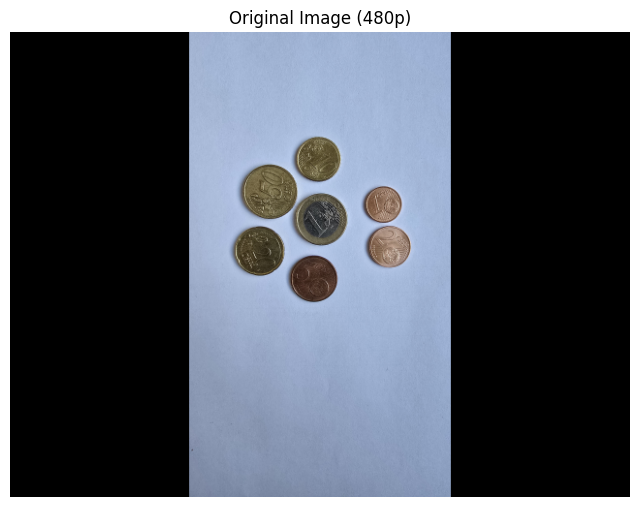

In [11]:
image_path = resolve_image_path(path)
image_bgr = read_bgr_or_raise(image_path)

image_bgr = letterbox_resize_to_canvas(image_bgr, TARGET_W, TARGET_H)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

show_image(image_rgb, "Original Image (480p)")


## 2) CLAHE (LAB) → grayscale

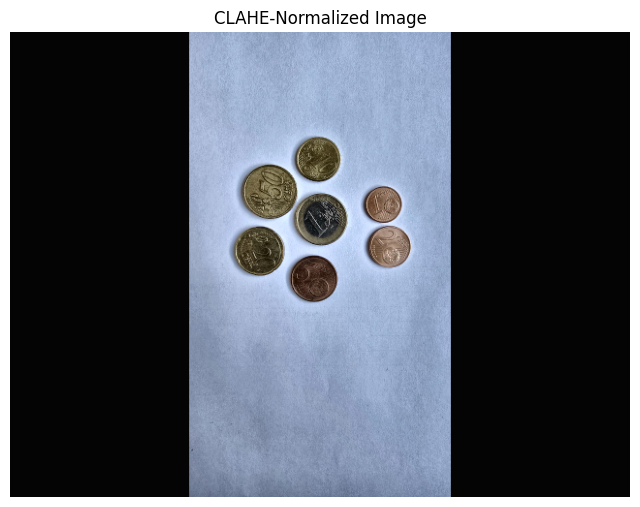

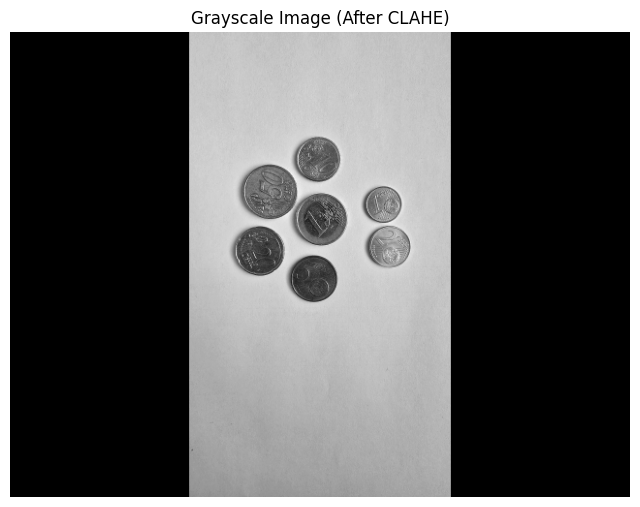

In [12]:
clahe_bgr, clahe_rgb = apply_clahe_on_l_channel(
    image_bgr,
    clip_limit=CLAHE_CLIP_LIMIT,
    tile_grid_size=CLAHE_TILE_GRID_SIZE,
)

show_image(clahe_rgb, "CLAHE-Normalized Image")

gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY) #clahe_bgr
show_image(gray, "Grayscale Image (After CLAHE)", cmap="gray")


## 3) Gaussian blur

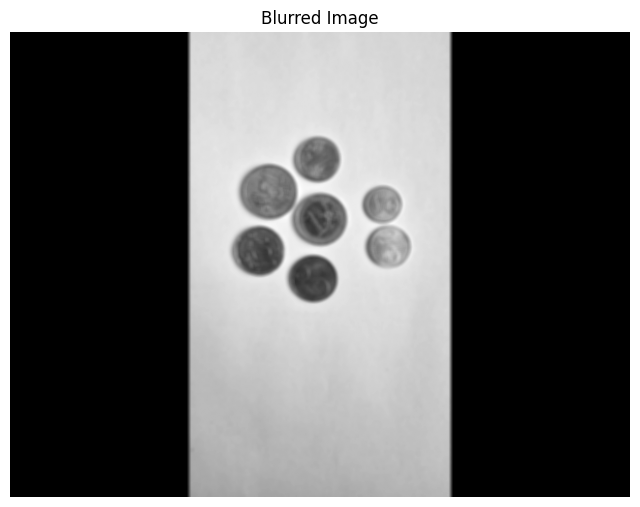

In [13]:
blurred = cv2.GaussianBlur(gray, (GAUSS_KSIZE, GAUSS_KSIZE), GAUSS_SIGMA)
show_image(blurred, "Blurred Image", cmap="gray")


## 4) Hough circles

Sweep results (minR -> n | nested | max_intrusions_in_one | intrusion_pairs | concentric_pairs):
   10 -> n=  7 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   12 -> n=  7 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   14 -> n=  7 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   16 -> n=  7 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   18 -> n=  6 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   20 -> n=  5 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   22 -> n=  5 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   24 -> n=  4 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   26 -> n=  3 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   28 -> n=  2 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   30 -> n=  0 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   32 -> n=  0 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   34 -> n=  0 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   36 

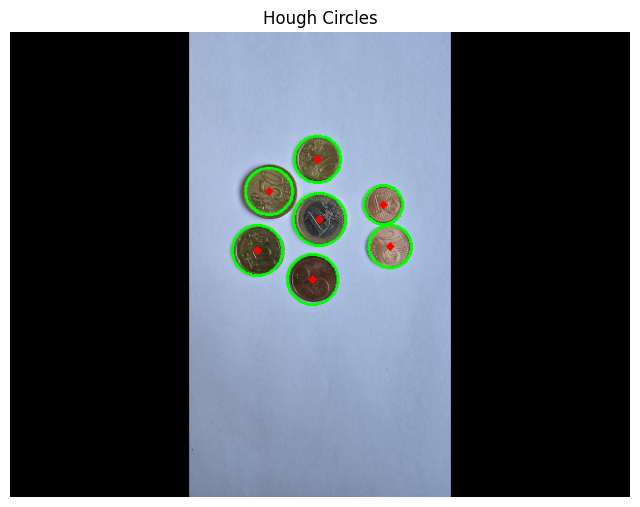

In [14]:
hough_params = HOUGH_PRESETS[ACTIVE_HOUGH_PRESET].copy()

# Dynamic param1 (NOT from preset)
param1 = auto_hough_param1_from_gradient(gray, blur_ksize=5, perc=65, scale=1.0, clamp=(30, 220)) #perc=70 
hough_params["param1"] = param1


# Dynamic min/max radius (NOT from preset)

#hough_params["minRadius"] = 5
hough_params["maxRadius"] = 100

best_minR, plate_dbg, sweep = auto_minradius_plateau(
    blurred,
    base_params=hough_params,
    minR_start=10,
    minR_end=min(140, hough_params["maxRadius"] - 1),
    step=2,
)

hough_params["minRadius"] = best_minR
print("plate_dbg:", plate_dbg)

circles = detect_hough_circles(blurred, hough_params)

output, count = draw_circles_on_rgb(image_rgb, circles)

print(f"param1(dynamic)={param1}")
if circles is not None:
    print(f"Found {count} circle(s)")
else:
    print("No circles found")

show_image(output, "Hough Circles")
